# Level 2 — Lesson 1: Understanding Data

**AI for Radiotherapy**

**Audience:** You know radiotherapy, medical imaging, and basic Python, but have little or no practical AI experience.

**Teaching time:** ~40–45 minutes  
**Core question:** *What information is available, what are we asking the model to learn, and is the dataset suitable for that task?*

This lesson intentionally contains **no neural network**.

Before choosing a model, we will ask:

1. What are \(X\) and \(y\)?
2. What information has preprocessing preserved or removed?
3. Who and what is represented in the dataset — and what is missing?
4. What is the correct independent unit for splitting?
5. Could leakage or shortcut information make performance look better than it really is?
6. What structure can we already see in the data?

> **Course principle:** A sophisticated model cannot recover information that was never presented to it.

## 0. Setup

We will use **OrganAMNIST**, part of MedMNIST.

OrganAMNIST is based on abdominal CT. The original Hounsfield-unit data were windowed to grayscale. Two-dimensional images were cropped from centre slices of organ bounding boxes in the axial plane and resized to 28×28 pixels. The task is 11-class organ classification.

The official split uses different source CT scans for training, validation, and test data: 115 / 16 / 70 scans respectively.

**Why this is useful for teaching:** the dataset is small and convenient, but it also demonstrates that the "data" presented to an AI model may already be the result of substantial preprocessing and problem design.

Sources:
- MedMNIST project: https://medmnist.com/
- Dataset metadata: https://github.com/MedMNIST/MedMNIST/blob/main/medmnist/info.py
- MedMNIST+ preprocessing notes: https://github.com/MedMNIST/MedMNIST/blob/main/on_medmnist_plus.md

In [ ]:
!pip -q install medmnist==3.0.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 3.6 MB/s eta 0:00:00


In [ ]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA

import torch
from torchvision import transforms
from torchvision.utils import make_grid

import medmnist
from medmnist import INFO

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("MedMNIST:", medmnist.__version__)

MedMNIST: 3.0.2


# 1. Define the learning problem before touching the model

For any supervised-learning problem, start by writing down:

```text
Unit of observation = ?
X                   = ?
y                   = ?
Task                = ?
Information present = ?
Information absent  = ?
```

For this dataset:

```text
Unit of observation = one preprocessed 2D image
X                   = 28 × 28 grayscale pixels
y                   = one of 11 organ classes
Task                = multiclass classification
```

The model will **not** receive the original CT volume. It will not see the full 3D anatomy, neighbouring slices, original HU values, voxel spacing, patient metadata, or the original position of the crop in the patient.

It can only learn relationships encoded in the 28×28 image we give it.

### The target is data too

We often focus on whether \(X\) contains the right information, but \(y\) also deserves scrutiny.

Ask:

- Who or what generated the target?
- How reproducible is it?
- Does it really represent the quantity we want the model to learn?

In radiotherapy, a contour is not necessarily unquestionable "ground truth", and a clinical dose distribution is one chosen treatment plan rather than the unique optimal dose distribution.

### Teaching pause — translate this to radiotherapy

Consider a dose-prediction problem.

Before discussing architectures, ask:

```text
What is X?
    CT?
    PTV?
    OAR masks?
    prescription?
    beam geometry?
    treatment technique?

What is y?
    voxel dose?
    DVH?
    clinical plan quality?

What relevant information is missing?
```

If beam arrangement strongly influences dose but beam information is absent from \(X\), the problem contains unavoidable ambiguity.

**Model design cannot repair an inadequately specified learning problem.**

# 2. Load the dataset

In [ ]:
DATA_FLAG = "organamnist"
IMAGE_SIZE = 28

info = INFO[DATA_FLAG]
DataClass = getattr(medmnist, info["python_class"])
transform = transforms.ToTensor()

train_dataset = DataClass(split="train", transform=transform, download=True, size=IMAGE_SIZE)
val_dataset = DataClass(split="val", transform=transform, download=True, size=IMAGE_SIZE)
test_dataset = DataClass(split="test", transform=transform, download=True, size=IMAGE_SIZE)

class_names = [info["label"][str(i)] for i in range(len(info["label"]))]

print("Task:", info["task"])
print("Channels:", info["n_channels"])
print("Classes:", len(class_names))
print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

100%|██████████| 38.2M/38.2M [00:42<00:00, 890kB/s]


Task: multi-class
Channels: 1
Classes: 11
Train: 34561
Validation: 6491
Test: 17778


## Inspect the object, not just the documentation

In [ ]:
image, target = train_dataset[0]
target_index = int(np.asarray(target).squeeze())

print("Image shape:", image.shape)
print("Image dtype:", image.dtype)
print("Value range:", float(image.min()), "to", float(image.max()))
print("Target:", target_index, "=", class_names[target_index])

Image shape: torch.Size([1, 28, 28])
Image dtype: torch.float32
Value range: 0.0 to 1.0
Target: 6 = liver


### What has happened to the CT values?

Clinical CT values are typically expressed in **Hounsfield Units (HU)**, which describe the linear attenuation coefficient of a material relative to water. By definition, water has a value of 0 HU, while air is approximately -1000 HU. In many radiotherapy CT datasets, image values are stored as integers and commonly span a range such as -1024 HU to +3071 HU after DICOM rescaling. The exact stored range depends on the scanner and image encoding.

In MedMNIST, the original CT data have already undergone substantial preprocessing. The images were windowed, converted to 8-bit grayscale, cropped, and resized. `ToTensor()` then converts those stored grayscale values to floating-point values approximately in the range `[0, 1]`.

These are **not the original Hounsfield Units**.

The model can learn from the representation provided by the dataset, but it cannot recover information discarded by the original windowing, cropping, or resizing.

### Key takeaway

Before designing a machine-learning application, ask:

> **Is the representation appropriate for the biological, physical, or clinical information we want the model to learn?**

Information loss is not automatically undesirable. Preprocessing can:

- remove irrelevant variation;
- reduce computational cost;
- standardize inputs;
- improve signal-to-noise ratio.

It becomes problematic when relevant information is removed. For example:

- aggressive clipping may remove high-density information;
- excessive downsampling may erase small structures;
- cropping may remove important spatial context;
- inconsistent preprocessing may introduce shortcuts.

> **Preprocessing is a trade-off: simplify the learning problem without discarding information needed to solve it.**

# 3. Understand the input: look at the images

The following code plots 16 randomly selected examples and their target labels.

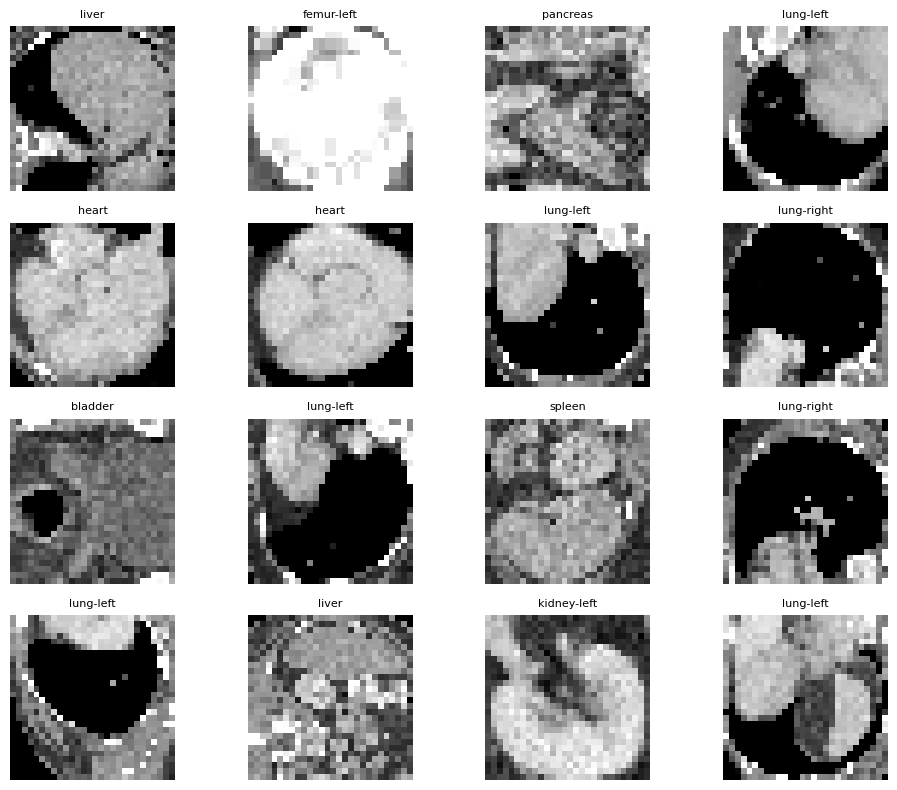

In [ ]:
rng = np.random.default_rng(SEED)
sample_indices = rng.choice(len(train_dataset), size=16, replace=False)

fig, axes = plt.subplots(4, 4, figsize=(10, 8))
for ax, idx in zip(axes.ravel(), sample_indices):
    image, target = train_dataset[int(idx)]
    label = int(np.asarray(target).squeeze())
    ax.imshow(image.squeeze(0), cmap="gray")
    ax.set_title(class_names[label], fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Exercise 1 — What information could a classifier use?

Suppose your task is to classify these images.

- Do the classes appear visually different?
- Which classes look similar?
- Could intensity, crop shape, left/right asymmetry, or another simple feature already help?
- Has the way these images were prepared made the task easier?

# 4. Understand the target distribution

We have inspected the **input**. Now inspect the **target labels**. The following code shows the frequency of the different classes in the training data.

,class_id,class_name,n_train,fraction
0,0,bladder,1956,0.056596
1,1,femur-left,1390,0.040219
2,2,femur-right,1357,0.039264
3,3,heart,1474,0.042649
4,4,kidney-left,3963,0.114667
5,5,kidney-right,3817,0.110442
6,6,liver,6164,0.178351
7,7,lung-left,3919,0.113394
8,8,lung-right,3929,0.113683
9,9,pancreas,3031,0.087700


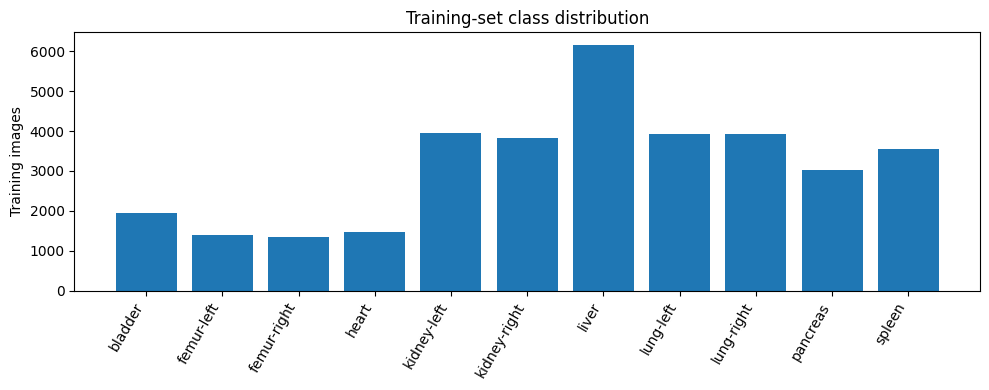

In [ ]:
train_labels = np.asarray(train_dataset.labels).squeeze()

counts = pd.Series(train_labels).value_counts().sort_index()
class_table = pd.DataFrame({
    "class_id": counts.index,
    "class_name": [class_names[i] for i in counts.index],
    "n_train": counts.values,
})
class_table["fraction"] = class_table["n_train"] / class_table["n_train"].sum()
display(class_table)

plt.figure(figsize=(10, 4))
plt.bar(class_table["class_name"], class_table["n_train"])
plt.xticks(rotation=60, ha="right")
plt.ylabel("Training images")
plt.title("Training-set class distribution")
plt.tight_layout()
plt.show()

### What does class imbalance mean?

Class imbalance can be a challenge, but it is not automatically a problem.

Ask:

- Does the observed distribution reflect the intended use population?
- Will common classes contribute disproportionately to the training objective?
- Are rare classes less, equally, or more important for the task?
- Could the chosen evaluation metric hide poor performance in a minority class?

> **The training distribution helps define what the model is encouraged to learn.**

### Look beyond the labels

A dataset can be balanced by target label and still represent only a narrow clinical population.

Relevant variation in radiotherapy may include:

- demographic or anatomical subgroups;
- metal implants or imaging artifacts;
- contrast-enhanced versus non-contrast imaging;
- immobilization techniques;
- scanners and reconstruction protocols;
- surgery or unusual anatomy;
- treatment techniques or institutions.

> **When looking at your data, also ask what is missing.**

Future cases may differ from the training distribution. This is broadly called **distribution shift**; clearly novel cases are often described as **out-of-distribution (OOD)**.

An underrepresented group is not automatically OOD: it may be present in the dataset but too sparse for reliable learning.

The practical question is:

> **Does the dataset represent the range of cases on which we expect the model to work?**

# 5. Understand how the data were split

OrganAMNIST contains many 2D images, but they originate from a much smaller number of CT scans.

This raises an important question:

> **How much data do we actually have: tens of thousands of images, or 115 training CT scans?**

Both numbers describe something useful, but they do not mean the same thing.

The network sees many images. However, images from the same source scan are correlated and are **not independent observations** for patient-level generalization.

> **More images do not necessarily mean more independent information.**  
> 10,000 patches extracted from 20 patients still represent only 20 independent patients when the scientific question is generalization to new patients.

The official OrganAMNIST split separates source CT scans between training, validation, and test data.

A dangerous workflow would be:

```text
extract images/patches from all patients
            ↓
randomly split the images
            ↓
train / validation / test
```

Images from the same patient could then appear on both sides of the split.

A safer pattern is:

```text
split patients/scans
        ↓
then create images/patches separately
```

This is a fundamental form of **data-leakage prevention**.

### Find the independent unit

For each RT task, ask which observations must remain together across a split:

- CT slices from the same patient;
- patches from the same CT;
- multiple fractions from the same patient;
- multiple plans for the same patient;
- repeated scans.

Institution is a related but different question:

> If data come from multiple centres, are we estimating performance on new patients from familiar centres, or generalization to a completely unseen centre?

The correct independent unit depends on the scientific question.

### Exercise 2 — Who compromised the evaluation?

Consider the following workflows.

#### Preprocessing

**Researcher A**
1. Calculates the minimum and maximum CT values across the **entire dataset**.
2. Uses these values to scale all CT data to `[0, 1]`.
3. Afterwards splits patients into training, validation, and test sets.

**Researcher B**
1. First splits patients into training, validation, and test sets.
2. Calculates the minimum and maximum separately for each split.
3. Scales each split independently to `[0, 1]`.

**Questions**
- Has information crossed a train/validation/test boundary?
- Does either workflow use the test cohort to define preprocessing?
- How should the scaling parameters be chosen instead?

---

#### Model development

**Researcher A**
1. Trains on the training set and develops the model using validation data.
2. Evaluates the final model on the held-out test set.
3. A test CT has an unexpected image shape and causes the input pipeline to fail.
4. Researcher A changes the input pipeline so the case can be processed, then evaluates again.

**Researcher B**
1. Trains and develops the model using training and validation data.
2. Evaluates on the held-out test set.
3. Test performance is disappointing.
4. Researcher B changes hyperparameters to improve test performance and evaluates again.

**Questions**
- Has either researcher contaminated the test set?
- Is the resulting test performance still an unbiased estimate of generalization?

### Discussion

The four situations are problematic for different reasons.

**Preprocessing A — data leakage**  
Scaling parameters were estimated from the entire dataset, so information from validation and test data influenced the preprocessing used for training.

**Preprocessing B — test-set contamination / transductive preprocessing**  
The training set itself was not fitted using test data, but the validation and test cohorts were used to define their own preprocessing. This makes evaluation depend on information unavailable for a single future patient and gives different splits different transforms.

For dataset-level preprocessing parameters, the usual workflow is:

```text
split patients
      ↓
fit preprocessing parameters on training data only
      ↓
apply the same transformation to
training, validation, and test data
```

This differs from a fixed rule such as a predefined HU window or another per-patient transform that requires no knowledge of the test cohort.

**Model A — subtle test-set contamination**  
The test case revealed an unanticipated input condition, and the pipeline was changed in response. The change may be sensible, but the original test set is no longer completely independent of development.

**Model B — direct tuning on the test set**  
The test result became feedback for hyperparameter selection. The test set has effectively become another validation set.

A clean workflow is:

```text
training set
    ↓
fit model parameters

validation set
    ↓
choose preprocessing, architecture,
hyperparameters, stopping criteria

test set
    ↓
final independent evaluation
```

> **A useful rule:** if information from a dataset changes how you preprocess, configure, select, or evaluate the model, that dataset has participated in model development.

> **Your brain is part of the model-development process.**

Once the test set influences a modelling decision, it is no longer a fully independent test set.

# 6. Simple and unintended predictive information


/tmp/ipykernel_3474/305882704.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_by_class, labels=class_names, showfliers=False)


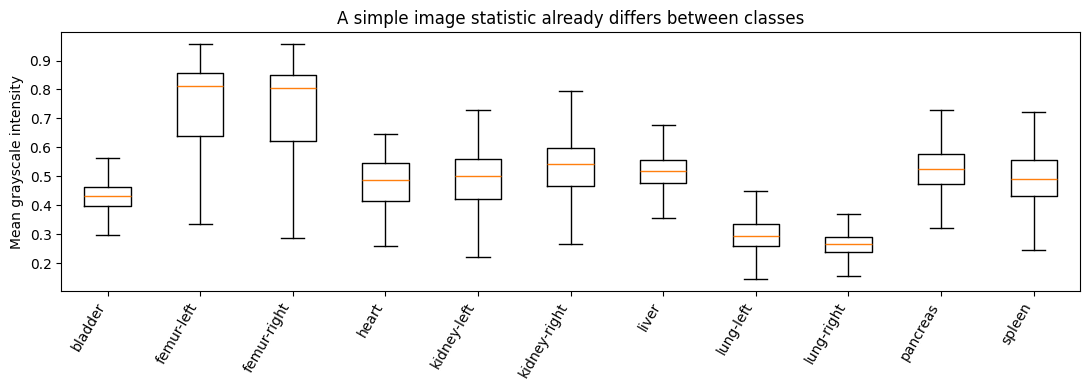

In [ ]:
raw_train = train_dataset.imgs.astype(np.float32) / 255.0
pixel_means = raw_train.reshape(len(raw_train), -1).mean(axis=1)

data_by_class = [
    pixel_means[train_labels == class_id]
    for class_id in range(len(class_names))
]

plt.figure(figsize=(11, 4))
plt.boxplot(data_by_class, labels=class_names, showfliers=False)
plt.xticks(rotation=60, ha="right")
plt.ylabel("Mean grayscale intensity")
plt.title("A simple image statistic already differs between classes")
plt.tight_layout()
plt.show()

A simple statistic being correlated with the target does **not** mean it solves the task.

It teaches an important habit:

> **Before celebrating a complex model, ask what simpler signals are already correlated with the target.**

Possible shortcuts in medical AI include field of view, crop position, resolution, scanner/site, reconstruction settings, treatment protocol, contouring conventions, or acquisition date.

A useful adversarial question is:

> **If I wanted to "cheat" at this task without learning the phenomenon I claim to study, what could I exploit?**

# 7. High-dimensional data: make a deliberately lossy map

Each 28×28 image contains \(28 \times 28 = 784\) pixel values.

We can think of one image as one point in a **784-dimensional input space**. Humans cannot inspect that point cloud directly, so we can project it into two dimensions.

For the core lesson we use **Principal Component Analysis (PCA)**:

> Find directions through the data that capture as much variance as possible.

High variance is **not** the same as high relevance to the prediction task. Scanner differences, patient size, cropping, or other nuisance factors could also contribute strongly to variance.

The 2D plot is therefore an exploratory, deliberately lossy view of the data.

In [ ]:
N_PROJECTION = min(3000, len(train_dataset))
rng = np.random.default_rng(SEED)
projection_indices = rng.choice(len(train_dataset), size=N_PROJECTION, replace=False)

projection_images = raw_train[projection_indices]
projection_labels = train_labels[projection_indices]
X_pixels = projection_images.reshape(N_PROJECTION, -1)

pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_pixels)

print("Original dimensions:", X_pixels.shape[1])
print("Projected dimensions:", X_pca.shape[1])
print("Variance explained by displayed components:",
      f"{pca.explained_variance_ratio_.sum():.1%}")

Original dimensions: 784
Projected dimensions: 2
Variance explained by displayed components: 39.4%


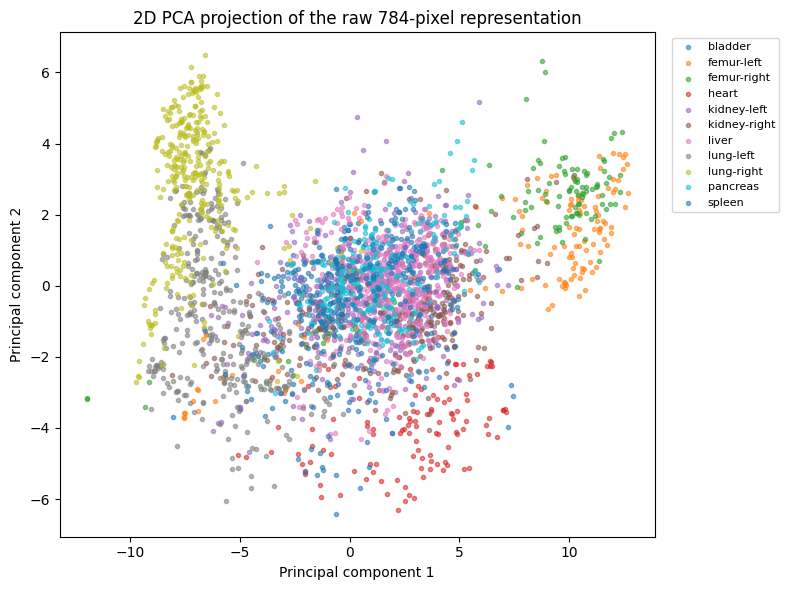

In [ ]:
plt.figure(figsize=(8, 6))

for class_id, class_name in enumerate(class_names):
    mask = projection_labels == class_id
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        s=9,
        alpha=0.55,
        label=class_name,
    )

plt.xlabel("Principal component 1")
plt.ylabel("Principal component 2")
plt.title("2D PCA projection of the raw 784-pixel representation")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

### Interpret carefully

Ask only limited questions:

- Do some classes occupy visibly different regions?
- Which classes overlap strongly?
- How much variance do the displayed components retain?
- Could target-relevant information exist in dimensions that are not shown?

Do **not** conclude that overlapping points are impossible to classify, or that separated clusters prove the task is easy.

```text
one image
    ↓
784-dimensional representation
    ↓
lossy 2D projection for human inspection
```

We will reuse this idea in Lesson 2 — except the representation will then be **learned by a neural network**.

# 8. Optional self-study — UMAP

PCA is linear. A nonlinear method such as **UMAP** can emphasize local neighbourhood structure differently.

UMAP can be useful for exploratory visualization, but it introduces additional assumptions and hyperparameters. Treat it as a visualization tool, not proof that classes are objectively clustered.

This section is **not part of the 40–45 minute core lesson**.

In [ ]:
# OPTIONAL
!pip -q install umap-learn

In [ ]:
# OPTIONAL
import umap.umap_ as umap

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=20,
    min_dist=0.15,
    metric="euclidean",
    random_state=SEED,
)
X_umap = reducer.fit_transform(X_pixels)

plt.figure(figsize=(8, 6))
for class_id, class_name in enumerate(class_names):
    mask = projection_labels == class_id
    plt.scatter(
        X_umap[mask, 0],
        X_umap[mask, 1],
        s=9,
        alpha=0.55,
        label=class_name,
    )
plt.xlabel("UMAP dimension 1")
plt.ylabel("UMAP dimension 2")
plt.title("Optional: UMAP of the raw-pixel representation")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

# 9. Exit exercise — define an RT learning problem

Your task is **particle-therapy dose prediction**.

You have collected planning CTs, RTSTRUCTs, and RTDOSE volumes from your institution.

Is that enough?

Write down:

```text
Unit of observation:
X:
y:

What information is present?
What relevant information might be missing?
Who or what generated y?
What preprocessing has already shaped X and y?
What is the correct independent unit for splitting?
What shortcut variables might predict y?
```

# 10. Take-home message

Before asking **"Which model should I use?"**, look for four kinds of failure:

### 1. Information problem
\(X\) does not contain what is needed to predict \(y\).

### 2. Representation problem
Preprocessing removes or distorts information needed for the task.

### 3. Dataset problem
The training data do not adequately represent the population or conditions on which the model must generalize.

### 4. Evaluation problem
Leakage, dependence between samples, or test-set contamination makes performance look more convincing than it really is.

A strong model cannot rescue a poorly defined learning problem.

In Lesson 2, we will finally train a neural network and ask how learning changes the representation of these same images.

---

## References

- MedMNIST: https://medmnist.com/
- MedMNIST repository and metadata: https://github.com/MedMNIST/MedMNIST
- Yang J, Shi R, Wei D, et al. *MedMNIST v2: A Large-Scale Lightweight Benchmark for 2D and 3D Biomedical Image Classification.* Scientific Data. 2023.
- OrganAMNIST is distributed by MedMNIST under CC BY 4.0.

This notebook is educational material and is not intended for clinical use.